# 2. Surface-temperature grid

Runs the solver over the temperature range in `run_toi561b.yaml` (`grid:` section). Temperatures that already have a converged output file are skipped.

In [81]:
from gce_tools import RunConfig, run_grid

cfg = RunConfig.from_yaml("run_toi561b.yaml")
print(cfg.network.summary())
print("Temperatures:", cfg.grid.temperatures)
print("Output dir:  ", cfg.run_dir)

Network 'MgSiO3_H2': elements Si, Mg, O, Fe, H, Na, C
  gas       (11): H2, H2O, CO, CO2, CH4, O2, Fe, Mg, SiO, Na, SiH4
  silicate  (11): MgO, SiO2, MgSiO3, FeO, FeSiO3, Na2O, Na2SiO3, H2, H2O, CO, CO2
  metal     ( 4): Fe, Si, O, H
Temperatures: [2500. 2600. 2700. 2800. 2900. 3000. 3100. 3200. 3300. 3400. 3500. 3600.
 3700. 3800. 3900. 4000.]
Output dir:   /Users/mcgintya/Documents/Python_scripts/GlobalChemicalEquilibrium_model/Standard_Version/runs/TOI_561b/Testing/MgSiO3/1000_bar


In [ ]:
results = run_grid(cfg)
results


[T=2500K] running solver...
Calculate the Gibbs Energies for the temperatures: 
[2500. 4500.]
Write Gibbs energies into file Gibbs.dat
Compare .dat ending -1
Compare .py ending 8
Start reading chemical inputfile
End reading chemical inputfile
Use ../Gibbs.py script to generate Gibbs energies file Gibbs.dat
Start reading Gibbs energy file Gibbs.dat
T_AMOI 2500 T_SME 4500
GRT 0 9.7123
GRT 1 2.15803
GRT 2 3.11234
GRT 3 -1.71133
GRT 4 -2.14927
GRT 5 1.40734
GRT 6 -17.5607
GRT 7 -3.30471
GRT 8 -24.7268
GRT 9 -5.11983
GRT 10 9.32445
GRT 11 9.84545
GRT 12 8.50039
GRT 13 -3.03401
GRT 14 11.3753
GRT 15 13.184
GRT 16 15.7538
GRT 17 14.6552
GRT 18 27.5657
End reading Gibbs energy file
1 5.37824e-15 0.867189 0.00505589 0.0985334 0.0167675 0.000346311 9.3902e-05 0.00784283 0.00417081 5.2602e-07 1.22427e-08 4.60261e-12 0.176864 0.268716 0.53237 0.0220497 0.920128 0.000215316 2.69826e-08 0.00011284 5.35789e-14 0.000708195 0.000823251 0.0252877 0.000565909 0.0521412 1.73453e-05 6.83719 1044.68 3243.6

## Quick look

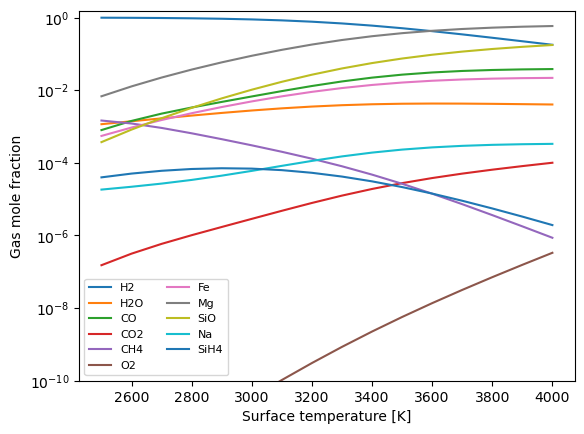

In [ ]:
import matplotlib.pyplot as plt

gas = cfg.network.phases["gas"]
fig, ax = plt.subplots()
for sp in gas.species:
    ax.semilogy(results["T_surface"], results[gas.column(sp)], label=sp)
ax.set_xlabel("Surface temperature [K]")
ax.set_ylabel("Gas mole fraction")
ax.set_ylim(1e-10, 1.5)
ax.legend(ncol=2, fontsize=8)
plt.show()

## Mass conservation check
**Left:** total planet mass from the converged element totals, as a fractional deviation from the nominal mass in the run YAML. This should stay at round-off level (around 1e-10 or smaller) at every temperature.

**Right:** surface pressure from the converged atmospheric mass, P = M_atm g / 4πR². Unlike the total mass, this is free to drift away from the input pressure (dashed line), because outgassing and dissolution move mass between the atmosphere and the melt.

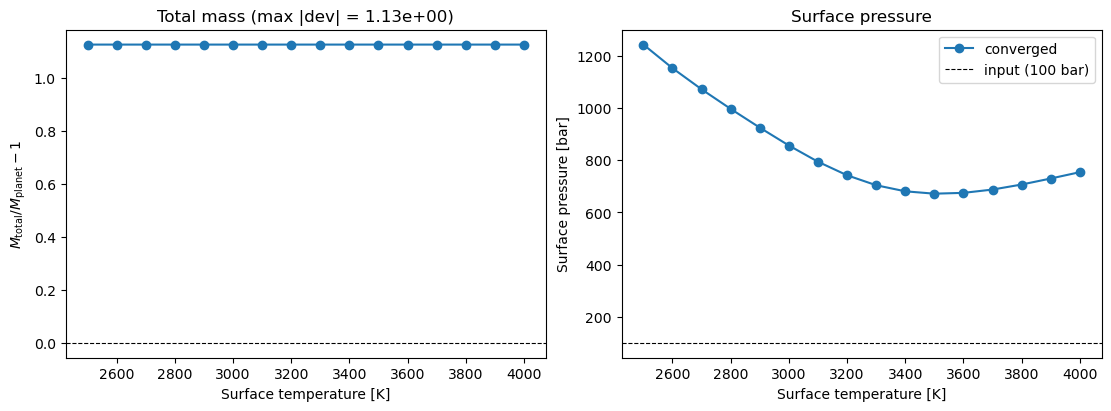

 T_surface  M_total_over_M_planet  P_surface_bar  mass_frac_gas  mass_frac_silicate  mass_frac_metal
    2500.0               2.127506    1243.044039       0.000877            0.766322         1.360307
    2600.0               2.127507    1152.591080       0.000813            0.752058         1.374636
    2700.0               2.127507    1071.643944       0.000756            0.740014         1.386737
    2800.0               2.127508     996.541690       0.000703            0.729666         1.397139
    2900.0               2.127505     924.711293       0.000652            0.720607         1.406247
    3000.0               2.127506     856.235952       0.000604            0.712521         1.414381
    3100.0               2.127508     794.013134       0.000560            0.705210         1.421737
    3200.0               2.127505     742.152105       0.000523            0.698544         1.428438
    3300.0               2.127509     703.938818       0.000496            0.692460        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = results["T_surface"]
dM = results["M_total_over_M_planet"] - 1.0
P = results["P_surface_bar"]
P0 = cfg.planet.surface_pressure_bar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

ax1.plot(T, dM, "o-")
ax1.axhline(0, color="k", lw=0.8, ls="--")
ax1.set_xlabel("Surface temperature [K]")
ax1.set_ylabel(r"$M_{\rm total}/M_{\rm planet} - 1$")
ax1.set_title(f"Total mass (max |dev| = {np.abs(dM).max():.2e})")
ax1.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

ax2.plot(T, P, "o-", label="converged")
ax2.axhline(P0, color="k", lw=0.8, ls="--", label=f"input ({P0:.0f} bar)")
ax2.set_xlabel("Surface temperature [K]")
ax2.set_ylabel("Surface pressure [bar]")
ax2.set_title("Surface pressure")
ax2.legend()

plt.show()

print(results[["T_surface", "M_total_over_M_planet", "P_surface_bar",
               "mass_frac_gas", "mass_frac_silicate", "mass_frac_metal"]].to_string(index=False))

In [ ]:
results['mass_frac_gas']+results['mass_frac_silicate']+results['mass_frac_metal']

0     2.127506
1     2.127507
2     2.127507
3     2.127508
4     2.127505
5     2.127506
6     2.127508
7     2.127505
8     2.127509
9     2.127506
10    2.127508
11    2.127508
12    2.127507
13    2.127507
14    2.127508
15    2.127509
dtype: float64

In [ ]:
#results.to_csv(cfg.run_dir / "grid_summary.csv", index=False)